# Slow Wave Analysis - Streamlined Time Alignment

This notebook provides an interactive analysis to comparing Widefield (WF) imaging-detected up and down states to electrophysiology detected down states.
- Contains section showing visual comparison of DOWN state detection on both datatypes, threshold optimization and precision metrics calculations


## Setup and Imports

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import pearsonr
from scipy import ndimage

## Configuration

### ⚙️ Main Settings - Edit These!

In [6]:
# File paths
BASE_PATH = '/Users/elisachinigo/Documents/Widefield_Data/mouse47/Conv/09102020'
SLOW_WAVES_FILE = f'{BASE_PATH}/09102020.SlowWaves.mat'
SLOW_WAVES_MUA_FILE = f'{BASE_PATH}/09102020.SlowWaves.events.mat'
MUA_FILE = f'{BASE_PATH}/09102020.MUA.lfp.mat'
WF_REGION_FILE = f'{BASE_PATH}/Processedvid4/WF_1/NREM_RegionPixels.mat'
OUTPUT_PATH = f'{BASE_PATH}/Processedvid4/WF_1/Dan_detection'

# Analysis parameters
SAMPLING_RATE_WF = 100  # Hz
REGION_NAME = 'RSPd1'  # Brain region to analyze

# ============================================================
# 🎯 TIME ALIGNMENT - SET THESE VALUES!
# ============================================================
# Specify the start and end times (in seconds) from the MUA timeline
# that correspond to your WF data snippet

WF_START_TIME_IN_MUA = 2705 # seconds - when does your WF snippet start in MUA time?
WF_END_TIME_IN_MUA = 3026    # seconds - when does your WF snippet end in MUA time?

# Optional: Analysis window within the aligned data
# (Leave as None to use the full aligned range)
ANALYSIS_START_TIME = None  # Can set to specific time, e.g., 2710
ANALYSIS_END_TIME = None    # Can set to specific time, e.g., 2850


# Percentile-based clipping for normalization
CLIP_LOW_PERCENTILE = 1   # Clip bottom 0.01%
CLIP_HIGH_PERCENTILE = 99  # Clip top 0.1%
# Signal filtering parameters
APPLY_FILTERING = True
LOW_PERCENTILE = 0.1
HIGH_PERCENTILE = 99.9
EVENT_WINDOW_SIZE = 50

## Data Loading Functions

In [7]:
def load_slow_waves(filepath):
    """Load slow wave data from .mat file"""
    data = loadmat(filepath)
    slow_waves = data['SlowWaves']
    SWpeakmag = slow_waves[0][0][1]
    ints = slow_waves[0][0][2][0][0][0]
    print(f"✓ Loaded slow waves from {filepath}")
    print(f"  Peak magnitude shape: {SWpeakmag.shape}")
    print(f"  Intervals shape: {ints.shape}")
    return SWpeakmag, ints

def load_mua_states(filepath):
    """Load MUA UP and DOWN states"""
    data = loadmat(filepath)
    
    # Uncomment for SlowWaves.Events.mat
    slow_waves = data['SlowWaves']
    slow_waves = slow_waves['ints']
    ups = slow_waves[0][0][0][0][0]
    downs = slow_waves[0][0][0][0][1]

    # Uncomment for SlowWavesMUA.events.mat
    #slow_waves = data['SlowWaves']
    #ups = slow_waves[0][0][0][0][0][0]
    #downs = slow_waves[0][0][0][0][0][1]
    print(f"✓ Loaded MUA states from {filepath}")
    print(f"  UP states: {ups.shape}")
    print(f"  DOWN states: {downs.shape}")
    return ups, downs

def load_mua_data(filepath):
    """Load MUA time series data from HDF5 file"""
    with h5py.File(filepath, 'r') as f:
        MUA = f['MUA']
        MUAdata = MUA['data'][:]
        MUAtimestamps = MUA['timestamps'][:]
    print(f"✓ Loaded MUA data from {filepath}")
    print(f"  Data shape: {MUAdata.shape}")
    print(f"  Timestamps shape: {MUAtimestamps.shape}")
    print(f"  Time range: {MUAtimestamps[0,0]:.2f} - {MUAtimestamps[0,-1]:.2f} seconds")
    return MUAdata, MUAtimestamps

def load_widefield_region(filepath, region_name):
    """Load widefield data for a specific brain region"""
    with h5py.File(filepath, 'r') as f:
        region = f['regionPixels'][region_name]
        region_average = region['regionAverage'][:].squeeze()
        linear_indices = region['linearIndices'][:]
        region_sum = region['regionSum'][:].squeeze()
        timeseries = region['timeseries'][:]
    print(f"✓ Loaded widefield data for {region_name}")
    print(f"  Region average shape: {region_average.shape}")
    print(f"  Duration: {len(region_average) / SAMPLING_RATE_WF:.2f} seconds")
    return region_average, linear_indices, region_sum, timeseries

## Load All Data

In [8]:
# Load all data
print("Loading data...\n")
SWpeakmag, ints = load_slow_waves(SLOW_WAVES_FILE)
ups, downs = load_mua_states(SLOW_WAVES_MUA_FILE)
MUAdata, MUAtimestamps = load_mua_data(MUA_FILE)
rspd_avg, linear_indices, region_sum, timeseries = load_widefield_region(WF_REGION_FILE, REGION_NAME)
print("\n✓ All data loaded successfully!")

Loading data...

✓ Loaded slow waves from /Users/elisachinigo/Documents/Widefield_Data/mouse47/Conv/09102020/09102020.SlowWaves.mat
  Peak magnitude shape: (7231, 1)
  Intervals shape: (7226, 2)
✓ Loaded MUA states from /Users/elisachinigo/Documents/Widefield_Data/mouse47/Conv/09102020/09102020.SlowWaves.events.mat
  UP states: (6291, 2)
  DOWN states: (6354, 2)
✓ Loaded MUA data from /Users/elisachinigo/Documents/Widefield_Data/mouse47/Conv/09102020/09102020.MUA.lfp.mat
  Data shape: (1, 9301275)
  Timestamps shape: (1, 9301275)
  Time range: 0.00 - 7441.02 seconds
✓ Loaded widefield data for RSPd1
  Region average shape: (32100,)
  Duration: 321.00 seconds

✓ All data loaded successfully!


## 🚀 Streamlined Time Alignment Function

In [9]:
def align_wf_to_mua(wf_data, wf_sampling_rate, 
                    mua_start_time, mua_end_time,
                    mua_timestamps, ups, downs,
                    analysis_start=None, analysis_end=None,
                    clip_low_percentile=0.01, clip_high_percentile=99.9,
                    apply_filtering=True, low_percentile=0.1, 
                    high_percentile=99.9, event_window_size=50):
    """
    Streamlined function to align WF data snippet to MUA timeline.
    
    Parameters:
    -----------
    wf_data : np.ndarray
        Raw widefield data (short snippet)
    wf_sampling_rate : float
        Sampling rate of WF data in Hz
    mua_start_time : float
        MUA time (seconds) corresponding to the start of WF data
    mua_end_time : float
        MUA time (seconds) corresponding to the end of WF data
    mua_timestamps : np.ndarray
        MUA timestamps
    ups : np.ndarray
        UP state intervals [N x 2]
    downs : np.ndarray
        DOWN state intervals [N x 2]
    analysis_start : float, optional
        Start time for analysis window (in MUA time). If None, uses mua_start_time
    analysis_end : float, optional
        End time for analysis window (in MUA time). If None, uses mua_end_time
    clip_low_percentile : float
        Lower percentile for clipping before normalization (default 0.01)
    clip_high_percentile : float
        Upper percentile for clipping before normalization (default 99.9)
    apply_filtering : bool
        Whether to filter abnormal signal segments
    low_percentile, high_percentile : float
        Percentile thresholds for filtering
    event_window_size : int
        Window around abnormal events to mark as invalid
        
    Returns:
    --------
    dict with keys:
        'wf_aligned' : WF data aligned to MUA timeline
        'wf_time' : Time vector for WF data in MUA coordinates
        'mua_binary' : Binary MUA state (UP=1, DOWN=0) interpolated to WF timepoints
        'valid_mask' : Boolean mask for valid (non-filtered) timepoints
        'ups_in_window' : UP states within the time window
        'downs_in_window' : DOWN states within the time window
        'alignment_info' : Dictionary with alignment statistics
    """
    
    print("\n" + "="*70)
    print("🎯 AUTOMATIC TIME ALIGNMENT")
    print("="*70)
    
    # Step 1: Create WF time vector in MUA coordinates
    wf_duration = len(wf_data) / wf_sampling_rate
    expected_duration = mua_end_time - mua_start_time
    
    print(f"\n1️⃣  WF Data Information:")
    print(f"   • WF snippet length: {len(wf_data)} samples")
    print(f"   • WF sampling rate: {wf_sampling_rate} Hz")
    print(f"   • WF duration: {wf_duration:.2f} seconds")
    print(f"   • Expected MUA duration: {expected_duration:.2f} seconds")
    
    if abs(wf_duration - expected_duration) > 1.0:
        print(f"   ⚠️  WARNING: Duration mismatch of {abs(wf_duration - expected_duration):.2f}s")
    
    # Create time vector for WF in MUA coordinates
    wf_time_mua = np.linspace(mua_start_time, mua_end_time, len(wf_data))
    
    print(f"\n2️⃣  Time Alignment:")
    print(f"   • WF time range in MUA coords: {wf_time_mua[0]:.2f} - {wf_time_mua[-1]:.2f} s")
    
    # Step 2: Clip and normalize WF data using percentiles
    print(f"\n2️⃣  Normalization with Percentile Clipping:")
    
    # Calculate percentile thresholds for clipping
    # Use provided clipping percentiles (already in parameters)
    
    low_clip = np.nanpercentile(wf_data, clip_low_percentile)
    high_clip = np.nanpercentile(wf_data, clip_high_percentile)
    
    print(f"   • Clipping range: [{low_clip:.4f}, {high_clip:.4f}]")
    print(f"   • Percentiles: [{clip_low_percentile}%, {clip_high_percentile}%]")
    
    # Clip the data
    wf_clipped = np.clip(wf_data, low_clip, high_clip)
    
    # Count how many values were clipped
    n_clipped_low = np.sum(wf_data < low_clip)
    n_clipped_high = np.sum(wf_data > high_clip)
    pct_clipped = 100 * (n_clipped_low + n_clipped_high) / len(wf_data)
    
    print(f"   • Clipped {n_clipped_low} low values, {n_clipped_high} high values")
    print(f"   • Total clipped: {pct_clipped:.2f}%")
    
    # Normalize to 0-1 range
    min_val = np.nanmin(wf_clipped)
    max_val = np.nanmax(wf_clipped)
    if max_val > min_val:
        wf_normalized = (wf_clipped - min_val) / (max_val - min_val)
        print(f"   • Normalized to [0, 1] range")
    else:
        wf_normalized = np.zeros_like(wf_clipped)
        print("   ⚠️  WARNING: Constant activity detected, normalized to zero")
    
    # Step 3: Apply filtering if requested
    valid_mask = np.ones(len(wf_normalized), dtype=bool)
    
    if apply_filtering:
        print(f"\n3️⃣  Signal Filtering:")
        low_thresh = np.nanpercentile(wf_normalized, low_percentile)
        high_thresh = np.nanpercentile(wf_normalized, high_percentile)
        
        abnormal_low = wf_normalized < low_thresh
        abnormal_high = wf_normalized > high_thresh
        abnormal_events = abnormal_low | abnormal_high
        
        invalid_mask = np.zeros(len(wf_normalized), dtype=bool)
        abnormal_indices = np.where(abnormal_events)[0]
        
        for idx in abnormal_indices:
            start = max(0, idx - event_window_size // 2)
            end = min(len(wf_normalized), idx + event_window_size // 2)
            invalid_mask[start:end] = True
        
        wf_normalized[invalid_mask] = np.nan
        valid_mask = ~invalid_mask
        
        n_invalid = np.sum(invalid_mask)
        pct_invalid = 100 * n_invalid / len(wf_normalized)
        
        print(f"   • Filtered {n_invalid} samples ({pct_invalid:.1f}%)")
        print(f"   • Thresholds: [{low_thresh:.4f}, {high_thresh:.4f}]")
    else:
        print(f"\n3️⃣  Signal Filtering: DISABLED")
    
    # Step 4: Set analysis window
    if analysis_start is None:
        analysis_start = mua_start_time
    if analysis_end is None:
        analysis_end = mua_end_time
    
    # Crop to analysis window
    window_mask = (wf_time_mua >= analysis_start) & (wf_time_mua <= analysis_end)
    wf_time_final = wf_time_mua[window_mask]
    wf_final = wf_normalized[window_mask]
    valid_mask_final = valid_mask[window_mask]
    
    print(f"\n4️⃣  Analysis Window:")
    print(f"   • Analysis time range: {analysis_start:.2f} - {analysis_end:.2f} s")
    print(f"   • Duration: {analysis_end - analysis_start:.2f} s")
    print(f"   • Number of WF samples: {len(wf_final)}")
    
    # Step 5: Find UP/DOWN states in the analysis window
    ups_in_window = ups[(ups[:, 0] >= analysis_start) & (ups[:, 1] <= analysis_end)]
    downs_in_window = downs[(downs[:, 0] >= analysis_start) & (downs[:, 1] <= analysis_end)]
    
    print(f"\n5️⃣  MUA States in Window:")
    print(f"   • UP states: {len(ups_in_window)}")
    print(f"   • DOWN states: {len(downs_in_window)}")
    
    # Step 6: Create binary MUA state vector at WF timepoints
    mua_binary = np.zeros(len(wf_time_final))
    for up_start, up_end in ups_in_window:
        in_up = (wf_time_final >= up_start) & (wf_time_final <= up_end)
        mua_binary[in_up] = 1
    
    # Also create labeled DOWN states for optimization
    mua_down_labeled = np.zeros(len(wf_time_final), dtype=int)
    for down_idx, (down_start, down_end) in enumerate(downs_in_window):
        in_down = (wf_time_final >= down_start) & (wf_time_final <= down_end)
        mua_down_labeled[in_down] = down_idx + 1
    
    print(f"\n6️⃣  Binary State Vector:")
    print(f"   • UP state coverage: {np.sum(mua_binary) / len(mua_binary) * 100:.1f}%")
    print(f"   • DOWN state coverage: {np.sum(mua_down_labeled > 0) / len(mua_down_labeled) * 100:.1f}%")
    
    # Compile alignment info
    alignment_info = {
        'wf_start_mua': mua_start_time,
        'wf_end_mua': mua_end_time,
        'analysis_start': analysis_start,
        'analysis_end': analysis_end,
        'wf_duration': wf_duration,
        'n_samples': len(wf_final),
        'n_ups': len(ups_in_window),
        'n_downs': len(downs_in_window),
        'pct_filtered': pct_invalid if apply_filtering else 0
    }
    
    print("\n" + "="*70)
    print("✅ ALIGNMENT COMPLETE!")
    print("="*70 + "\n")
    
    return {
        'wf_aligned': wf_final,
        'wf_time': wf_time_final,
        'mua_binary': mua_binary,
        'mua_down_labeled': mua_down_labeled,
        'valid_mask': valid_mask_final,
        'ups_in_window': ups_in_window,
        'downs_in_window': downs_in_window,
        'alignment_info': alignment_info
    }

## 🎯 Align Data (One Simple Function Call!)

In [10]:
# Align WF data to MUA timeline - just specify start and end times!
aligned_data = align_wf_to_mua(
    wf_data=rspd_avg,
    wf_sampling_rate=SAMPLING_RATE_WF,
    mua_start_time=WF_START_TIME_IN_MUA,
    mua_end_time=WF_END_TIME_IN_MUA,
    mua_timestamps=MUAtimestamps,
    ups=ups,
    downs=downs,
    analysis_start=ANALYSIS_START_TIME,
    analysis_end=ANALYSIS_END_TIME,
    clip_low_percentile=CLIP_LOW_PERCENTILE,
    clip_high_percentile=CLIP_HIGH_PERCENTILE,
    apply_filtering=APPLY_FILTERING,
    low_percentile=LOW_PERCENTILE,
    high_percentile=HIGH_PERCENTILE,
    event_window_size=EVENT_WINDOW_SIZE
)

# Unpack results for easy access
wf_aligned = aligned_data['wf_aligned']
wf_time = aligned_data['wf_time']
mua_binary = aligned_data['mua_binary']
mua_down_labeled = aligned_data['mua_down_labeled']
valid_mask = aligned_data['valid_mask']
ups_in_window = aligned_data['ups_in_window']
downs_in_window = aligned_data['downs_in_window']


🎯 AUTOMATIC TIME ALIGNMENT

1️⃣  WF Data Information:
   • WF snippet length: 32100 samples
   • WF sampling rate: 100 Hz
   • WF duration: 321.00 seconds
   • Expected MUA duration: 321.00 seconds

2️⃣  Time Alignment:
   • WF time range in MUA coords: 2705.00 - 3026.00 s

2️⃣  Normalization with Percentile Clipping:
   • Clipping range: [-0.0746, 0.0936]
   • Percentiles: [1%, 99%]
   • Clipped 321 low values, 321 high values
   • Total clipped: 2.00%
   • Normalized to [0, 1] range

3️⃣  Signal Filtering:
   • Filtered 0 samples (0.0%)
   • Thresholds: [0.0000, 1.0000]

4️⃣  Analysis Window:
   • Analysis time range: 2705.00 - 3026.00 s
   • Duration: 321.00 s
   • Number of WF samples: 32100

5️⃣  MUA States in Window:
   • UP states: 653
   • DOWN states: 654

6️⃣  Binary State Vector:
   • UP state coverage: 71.1%
   • DOWN state coverage: 28.8%

✅ ALIGNMENT COMPLETE!



## Visualization Functions

In [11]:
def plot_aligned_data(wf_time, wf_data, mua_timestamps, mua_data, 
                     ups, downs, valid_mask=None, time_range=None, threshold=None):
    """
    Plot aligned WF and MUA data with UP/DOWN states.
    
    For widefield plot: Shows WF-detected DOWN states (if threshold provided)
    For MUA plot: Shows MUA-detected DOWN states (ground truth)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    
    # Plot widefield data
    # Add alternating background shading for WF-DETECTED DOWN states (if threshold provided)
    if threshold is not None:
        # Detect DOWN states from WF data using threshold
        # Handle NaN values by treating them as neutral (neither UP nor DOWN for detection)
        wf_clean = np.where(np.isnan(wf_data), threshold, wf_data)  # Replace NaN with threshold
        wf_binary = (wf_clean > threshold).astype(int)  # 1 = UP, 0 = DOWN
        
        # Find transitions to identify DOWN state segments
        # Pad with 1 (UP state) at boundaries to catch edge cases
        padded = np.concatenate([[1], wf_binary, [1]])
        wf_state_changes = np.diff(padded)
        down_starts = np.where(wf_state_changes == -1)[0]  # Transitions from UP to DOWN
        down_ends = np.where(wf_state_changes == 1)[0]      # Transitions from DOWN to UP
        
        # Plot alternating background for WF-detected DOWN states
        for i, (start_idx, end_idx) in enumerate(zip(down_starts, down_ends)):
            # Make sure indices are valid
            if start_idx < len(wf_time) and end_idx <= len(wf_time):
                start_time = wf_time[start_idx]
                # end_idx points to first UP sample, so use end_idx-1 for last DOWN sample
                end_time = wf_time[min(end_idx, len(wf_time)-1)]
                # Alternate between gray and white for consecutive DOWN states
                color = 'lightgray'
                ax1.axvspan(start_time, end_time, color=color, alpha=0.5, zorder=0)
    
    if valid_mask is not None:
        # Show filtered regions
        ax1.fill_between(wf_time, -1, 2, where=~valid_mask, 
                        color='red', alpha=0.2, label='Filtered', zorder=1)
    
    ax1.plot(wf_time, wf_data, 'b-', linewidth=1, label='WF Activity', zorder=2)
    
    # Add threshold line if provided
    if threshold is not None:
        ax1.axhline(y=threshold, color='r', linestyle='--', linewidth=2, 
                   label=f'Threshold = {threshold:.3f}', zorder=3)
    
    ax1.set_ylabel('WF Activity (normalized)')
    title_suffix = ' (WF-detected states)' if threshold is not None else ''
    ax1.set_title(f'{REGION_NAME} Widefield Activity{title_suffix}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot MUA data with alternating background for MUA-detected DOWN states
    for i, (start, end) in enumerate(downs):
        # Alternate between gray and white for consecutive DOWN states
        color = 'lightgray' 
        ax2.axvspan(start, end, color=color, alpha=0.5, zorder=0)
    
    ax2.plot(mua_timestamps.flatten(), mua_data.flatten(), 'k-', linewidth=0.5, alpha=0.8, zorder=1)
    
    ax2.set_ylabel('MUA Activity')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_title('MUA Activity with UP/DOWN States (MUA-detected)')
    ax2.set_yscale('log')
    ax2.set_ylim(50,800)
    ax2.grid(True, alpha=0.3)
    
    if time_range is not None:
        ax1.set_xlim(time_range)
    
    plt.tight_layout()
    return fig

def plot_state_comparison(wf_time, wf_data, mua_binary, valid_mask=None, time_range=None, threshold=None, downs=None):
    """
    Compare WF activity with binary MUA state.
    
    For widefield plot: Shows WF-detected DOWN states (if threshold provided)
    For MUA plot: Shows MUA binary state (ground truth)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    
    # Plot WF data with alternating WF-DETECTED DOWN state background (if threshold provided)
    if threshold is not None:
        # Detect DOWN states from WF data using threshold
        # Handle NaN values by treating them as neutral (neither UP nor DOWN for detection)
        wf_clean = np.where(np.isnan(wf_data), threshold, wf_data)  # Replace NaN with threshold
        wf_binary = (wf_clean > threshold).astype(int)  # 1 = UP, 0 = DOWN
        
        # Find transitions to identify DOWN state segments
        # Pad with 1 (UP state) at boundaries to catch edge cases
        padded = np.concatenate([[1], wf_binary, [1]])
        wf_state_changes = np.diff(padded)
        down_starts = np.where(wf_state_changes == -1)[0]  # Transitions from UP to DOWN
        down_ends = np.where(wf_state_changes == 1)[0]      # Transitions from DOWN to UP
        
        # Plot alternating background for WF-detected DOWN states
        for i, (start_idx, end_idx) in enumerate(zip(down_starts, down_ends)):
            # Make sure indices are valid
            if start_idx < len(wf_time) and end_idx <= len(wf_time):
                start_time = wf_time[start_idx]
                # end_idx points to first UP sample, so use end_idx-1 for last DOWN sample
                end_time = wf_time[min(end_idx, len(wf_time)-1)]
                # Alternate between gray and white for consecutive DOWN states
                color = 'lightgray' if i % 2 == 0 else 'white'
                ax1.axvspan(start_time, end_time, color=color, alpha=0.5, zorder=0)
    
    if valid_mask is not None:
        ax1.fill_between(wf_time, -1, 2, where=~valid_mask, 
                        color='red', alpha=0.2, label='Filtered', zorder=1)
    
    ax1.plot(wf_time, wf_data, 'b-', linewidth=1, label='WF Activity', zorder=2)
    
    # Add threshold line if provided
    if threshold is not None:
        ax1.axhline(y=threshold, color='r', linestyle='--', linewidth=2, 
                   label=f'Threshold = {threshold:.3f}', zorder=3)
    
    ax1.set_ylabel('WF Activity')
    title_suffix = ' (WF-detected states)' if threshold is not None else ''
    ax1.set_title(f'Widefield Activity{title_suffix}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot binary MUA state
    ax2.plot(wf_time, mua_binary, 'r-', linewidth=2, label='MUA State')
    ax2.fill_between(wf_time, 0, 1, where=mua_binary > 0.5, 
                     color='red', alpha=0.3, label='UP')
    ax2.fill_between(wf_time, 0, 1, where=mua_binary < 0.5, 
                     color='blue', alpha=0.3, label='DOWN')
    ax2.set_ylabel('State (1=UP, 0=DOWN)')
    ax2.set_xlabel('Time (seconds)')
    ax2.set_title('Binary MUA State (ground truth)')
    ax2.set_ylim(-0.1, 1.1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    if time_range is not None:
        ax1.set_xlim(time_range)
    
    plt.tight_layout()
    return fig

## Visualize Aligned Data

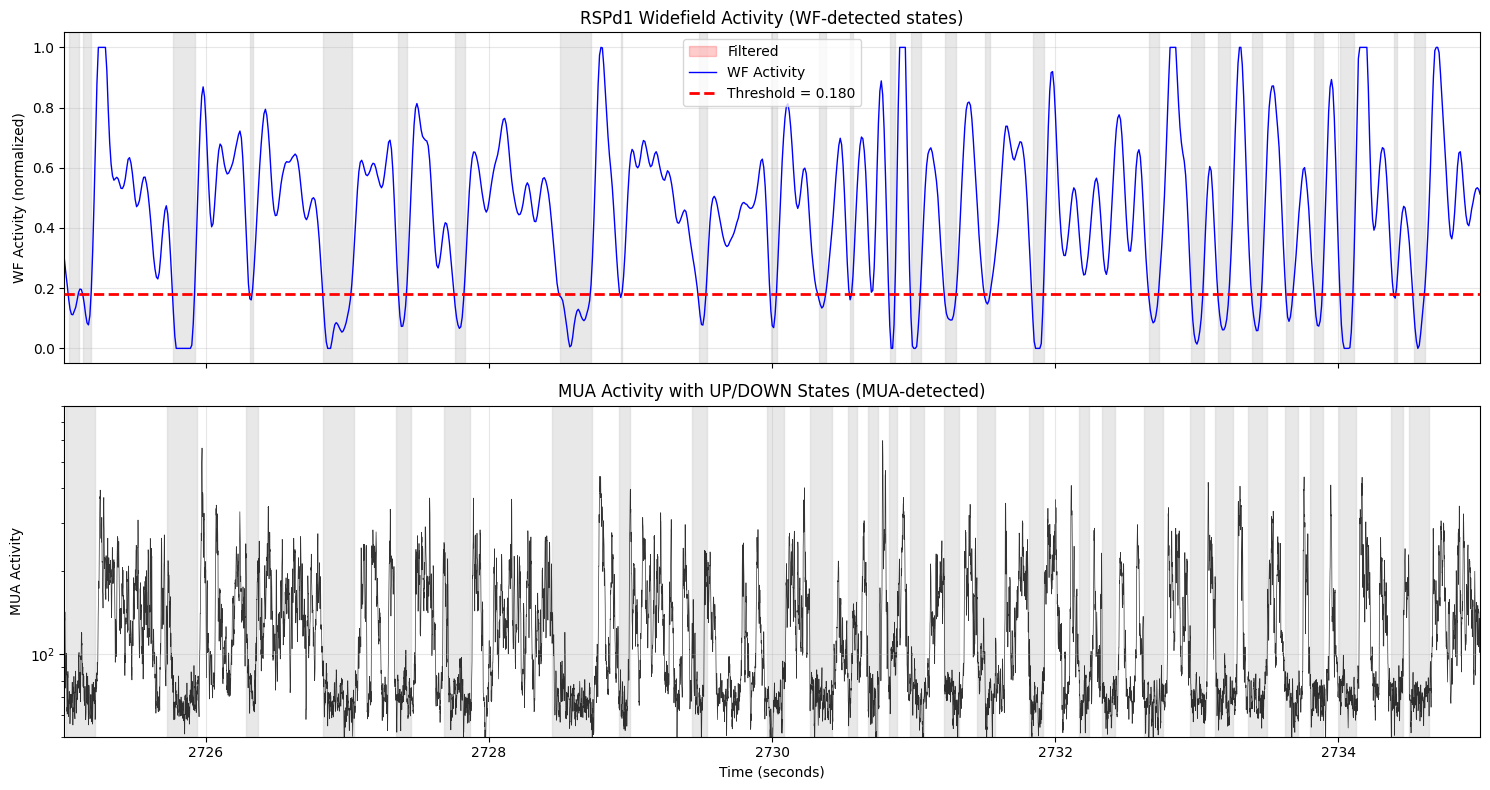


Saved to: /Users/elisachinigo/Documents/Widefield_Data/mouse47/Conv/09102020/Processedvid4/WF_1/Dan_detection/aligned_data_overview_short.pdf


In [12]:
# Plot overview of aligned data
time_range = (WF_START_TIME_IN_MUA, min(WF_START_TIME_IN_MUA + 30, WF_END_TIME_IN_MUA))
time_range =  (2725,2735)
fig1 = plot_aligned_data(
    wf_time, wf_aligned, 
    MUAtimestamps, MUAdata,
    ups_in_window, downs_in_window,
    valid_mask=valid_mask,
    time_range=time_range,
    threshold=0.18  # Uncomment after running threshold optimization
)
plt.savefig(f'{OUTPUT_PATH}/aligned_data_overview_short.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {OUTPUT_PATH}/aligned_data_overview_short.pdf")

## State Comparison

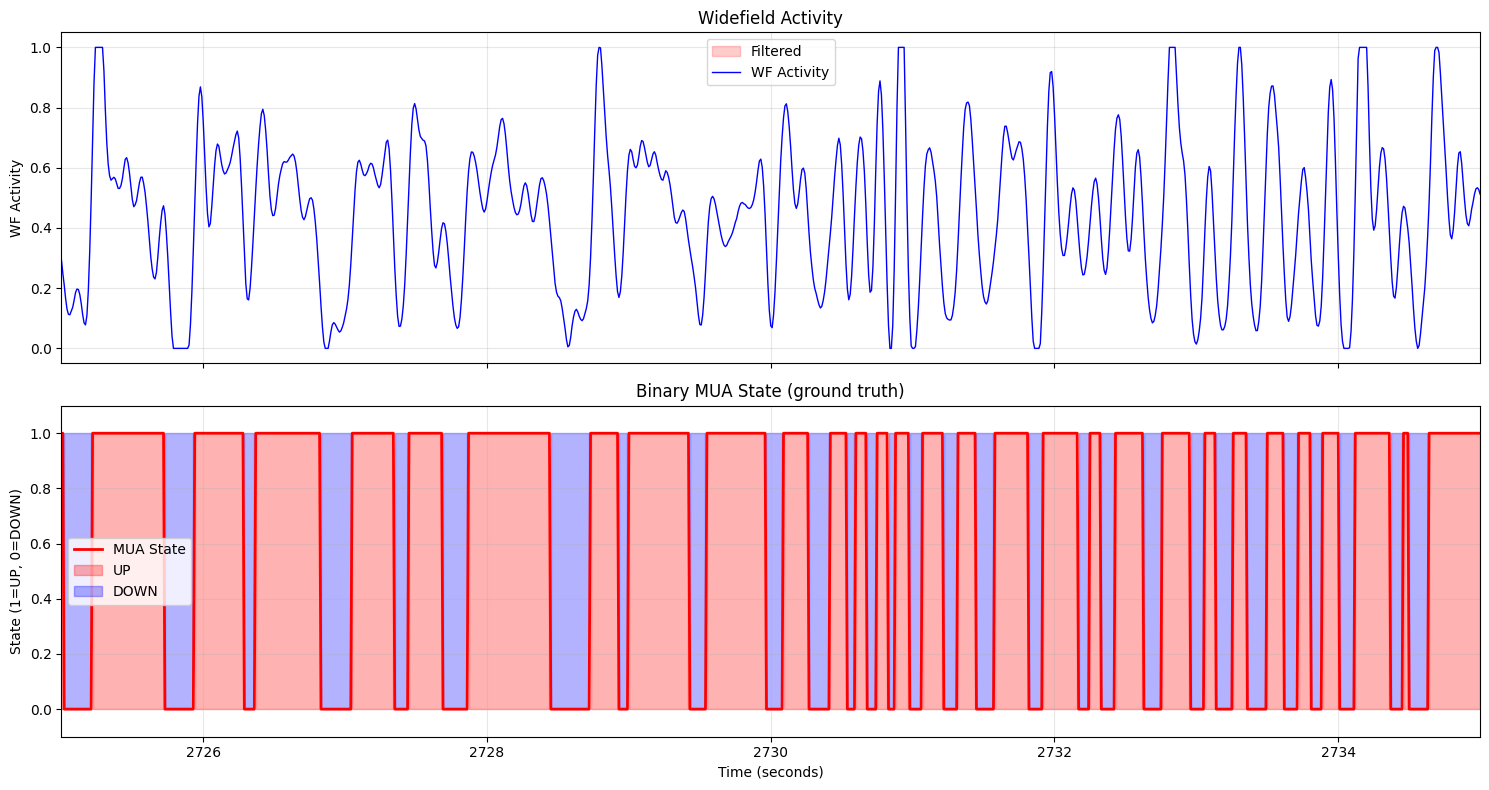


Saved to: /Users/elisachinigo/Documents/Widefield_Data/mouse47/Conv/09102020/Processedvid4/WF_1/Dan_detection/state_comparison.pdf


In [13]:
# Plot state comparison
fig2 = plot_state_comparison(
    wf_time, wf_aligned, mua_binary,
    valid_mask=valid_mask,
    time_range=time_range
    # threshold=optimal_threshold  # Uncomment after running threshold optimization
)
plt.savefig(f'{OUTPUT_PATH}/state_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {OUTPUT_PATH}/state_comparison.pdf")

## Threshold Optimization (Optional)

Functions for finding optimal threshold to detect UP/DOWN states from WF data.

In [14]:
def optimize_threshold(wf_data, mua_binary, mua_down_labeled, n_downs, 
                                        valid_mask=None, thresholds=None):
    """
    Find optimal threshold for detecting DOWN states from WF data.
    
    MODIFIED VERSION: Treats DOWN states as the "positive" class we want to detect.
    
    Now the metrics mean:
    - Precision: When WF says DOWN, how often is it actually DOWN?
    - Recall: Of all actual DOWN states, how many did WF catch?
    - F1: Balance of DOWN detection precision and recall
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.9, 81)
    
    if valid_mask is None:
        valid_mask = np.ones(len(wf_data), dtype=bool)
    
    # Use only valid data
    wf_valid = wf_data[valid_mask]
    mua_binary_valid = mua_binary[valid_mask]
    mua_down_labeled_valid = mua_down_labeled[valid_mask]
    
    results = []
    
    for thresh in thresholds:
        # Detect states in WF
        wf_binary = (wf_valid > thresh).astype(int)  # 1 = UP, 0 = DOWN
        
        # FLIP THE LOGIC: Now we treat DOWN (0) as the positive class
        wf_down = 1 - wf_binary  # Convert to: 1 = DOWN, 0 = UP
        mua_down = 1 - mua_binary_valid  # Convert MUA to: 1 = DOWN, 0 = UP
        
        # Calculate metrics FOR DOWN STATE DETECTION
        # True Positive: WF says DOWN, MUA confirms DOWN
        tp = np.sum((wf_down == 1) & (mua_down == 1))
        # False Positive: WF says DOWN, but MUA says UP
        fp = np.sum((wf_down == 1) & (mua_down == 0))
        # True Negative: WF says UP, MUA confirms UP
        tn = np.sum((wf_down == 0) & (mua_down == 0))
        # False Negative: WF says UP, but MUA says DOWN (missed a DOWN state)
        fn = np.sum((wf_down == 0) & (mua_down == 1))
        
        # Metrics now reflect DOWN state detection performance
        accuracy = (tp + tn) / (tp + fp + tn + fn) if (tp + fp + tn + fn) > 0 else 0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0  # When WF says DOWN, % actually DOWN
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Of all actual DOWNs, % caught by WF
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        # Calculate correlation
        if len(wf_down) > 0:
            corr, _ = pearsonr(wf_down, mua_down)
        else:
            corr = 0
        
        results.append({
            'threshold': thresh,
            'accuracy': accuracy,
            'precision': precision,  # Now for DOWN states
            'recall': recall,  # Now for DOWN states
            'f1_score': f1,  # Now for DOWN states
            'correlation': corr,
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn
        })
    
    return results


def plot_threshold_results(results):
    """
    Plot threshold optimization results focused on DOWN state detection.
    
    MODIFIED VERSION: All metrics now reflect DOWN state detection performance.
    """
    thresholds = [r['threshold'] for r in results]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot accuracy
    axes[0, 0].plot(thresholds, [r['accuracy'] for r in results], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Threshold')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_title('Accuracy vs Threshold\n(Overall correctness for DOWN state detection)')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot F1 score
    f1_scores = [r['f1_score'] for r in results]
    axes[0, 1].plot(thresholds, f1_scores, 'g-', linewidth=2)
    best_idx = np.argmax(f1_scores)
    axes[0, 1].plot(thresholds[best_idx], f1_scores[best_idx], 'r*', markersize=15, 
                    label=f'Best: {thresholds[best_idx]:.3f}')
    axes[0, 1].set_xlabel('Threshold')
    axes[0, 1].set_ylabel('F1 Score')
    axes[0, 1].set_title('F1 Score vs Threshold\n(Balance of DOWN state precision & recall)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot precision and recall
    axes[1, 0].plot(thresholds, [r['precision'] for r in results], 'r-', 
                    linewidth=2, label='Precision (DOWN)')
    axes[1, 0].plot(thresholds, [r['recall'] for r in results], 'b-', 
                    linewidth=2, label='Recall (DOWN)')
    axes[1, 0].set_xlabel('Threshold')
    axes[1, 0].set_ylabel('Score')
    axes[1, 0].set_title('Precision and Recall vs Threshold\n(For DOWN state detection)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot correlation
    axes[1, 1].plot(thresholds, [r['correlation'] for r in results], 'm-', linewidth=2)
    axes[1, 1].set_xlabel('Threshold')
    axes[1, 1].set_ylabel('Correlation')
    axes[1, 1].set_title('Correlation vs Threshold\n(WF DOWN states vs MUA DOWN states)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print detailed results
    best_result = results[best_idx]
    print(f"\n🎯 Optimal Threshold for DOWN State Detection: {thresholds[best_idx]:.3f}")
    print(f"   (WF values BELOW this threshold = DOWN state)")
    print(f"\n📊 Performance Metrics:")
    print(f"   Max F1 Score: {f1_scores[best_idx]:.3f}")
    print(f"   Accuracy: {best_result['accuracy']:.3f}")
    print(f"   Precision: {best_result['precision']:.3f} (When WF says DOWN, % actually DOWN)")
    print(f"   Recall: {best_result['recall']:.3f} (Of all actual DOWNs, % caught by WF)")
    print(f"\n🔍 Confusion Matrix at Optimal Threshold:")
    print(f"   True Positives (correct DOWN detections): {best_result['tp']}")
    print(f"   False Positives (false DOWN alarms): {best_result['fp']}")
    print(f"   True Negatives (correct UP detections): {best_result['tn']}")
    print(f"   False Negatives (missed DOWN states): {best_result['fn']}")
    
    return fig, thresholds[best_idx], f1_scores[best_idx]

## Run Threshold Optimization

Running threshold optimization...

🎯 Optimal Threshold for DOWN State Detection: 0.355
   (WF values BELOW this threshold = DOWN state)

📊 Performance Metrics:
   Max F1 Score: 0.768
   Accuracy: 0.860
   Precision: 0.738 (When WF says DOWN, % actually DOWN)
   Recall: 0.800 (Of all actual DOWNs, % caught by WF)

🔍 Confusion Matrix at Optimal Threshold:
   True Positives (correct DOWN detections): 7414
   False Positives (false DOWN alarms): 2632
   True Negatives (correct UP detections): 20205
   False Negatives (missed DOWN states): 1849


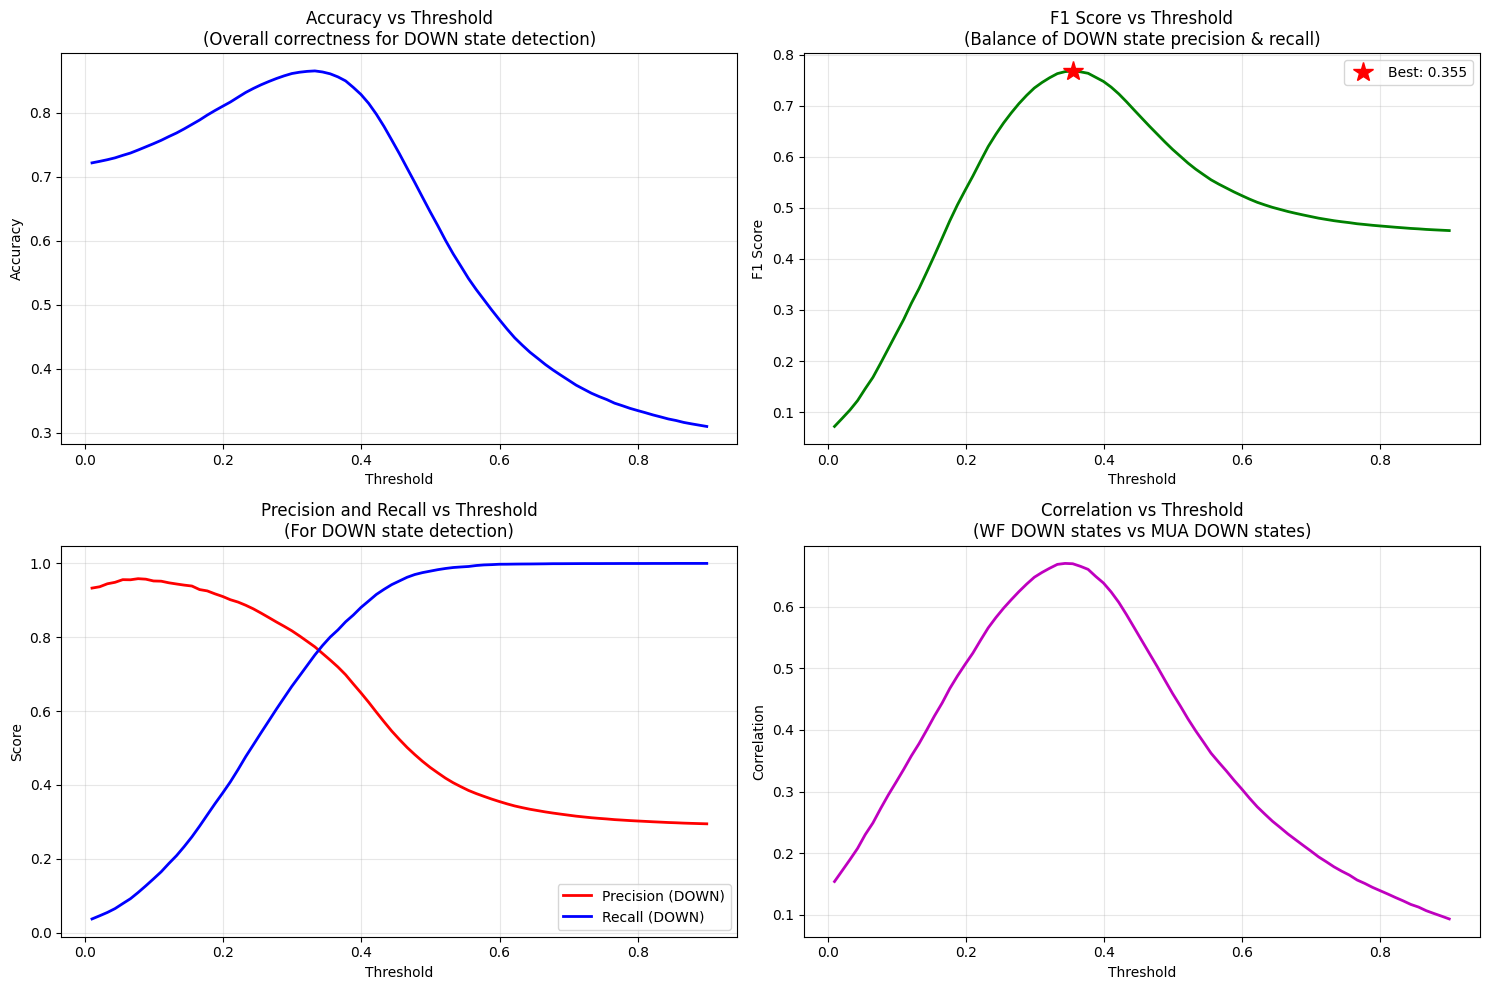


Saved to: /Users/elisachinigo/Documents/Widefield_Data/mouse47/Conv/09102020/Processedvid4/WF_1/Dan_detection/threshold_optimization.pdf


In [15]:
# Optimize threshold
print("Running threshold optimization...")
optimization_results = optimize_threshold(
    wf_aligned, 
    mua_binary, 
    mua_down_labeled,
    len(downs_in_window),
    valid_mask=valid_mask
)

# Plot results
fig_opt, optimal_threshold, max_f1 = plot_threshold_results(optimization_results)
plt.savefig(f'{OUTPUT_PATH}/threshold_optimization.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSaved to: {OUTPUT_PATH}/threshold_optimization.pdf")

In [16]:
def calculate_down_state_detection_with_precision(wf_time, wf_data, mua_downs, threshold):
    """
    Calculate bidirectional metrics for DOWN state detection:
    1. Recall/Sensitivity: % of MUA DOWN states detected by WF (you care about detecting them)
    2. Precision: % of WF DOWN states that correspond to real MUA DOWN states (accuracy of WF)
    
    Parameters:
    -----------
    wf_time : np.ndarray
        Time vector for WF data (in MUA coordinates)
    wf_data : np.ndarray
        Widefield activity data (normalized)
    mua_downs : np.ndarray
        MUA DOWN state intervals [N x 2] with [start_time, end_time]
    threshold : float
        Threshold for detecting DOWN states in WF (values < threshold = DOWN)
    
    Returns:
    --------
    dict with:
        'recall': Percentage of MUA DOWN states with any WF overlap (sensitivity)
        'precision': Percentage of WF DOWN states with any MUA overlap (accuracy)
        'n_mua_downs': Total number of MUA DOWN states
        'n_wf_downs': Total number of WF DOWN states
        'n_mua_detected': Number of MUA DOWN states with WF overlap
        'n_mua_missed': Number of MUA DOWN states with no WF overlap
        'n_wf_correct': Number of WF DOWN states with MUA overlap
        'n_wf_false': Number of WF DOWN states with no MUA overlap (false alarms)
    """
    
    # Detect DOWN states in WF data
    wf_clean = np.where(np.isnan(wf_data), threshold, wf_data)
    wf_binary = (wf_clean > threshold).astype(int)  # 1 = UP, 0 = DOWN
    
    # Find WF DOWN state segments
    padded = np.concatenate([[1], wf_binary, [1]])
    wf_state_changes = np.diff(padded)
    down_starts_idx = np.where(wf_state_changes == -1)[0]
    down_ends_idx = np.where(wf_state_changes == 1)[0]
    
    # Convert indices to times
    wf_down_intervals = []
    for start_idx, end_idx in zip(down_starts_idx, down_ends_idx):
        if start_idx < len(wf_time) and end_idx <= len(wf_time):
            start_time = wf_time[start_idx]
            end_time = wf_time[min(end_idx, len(wf_time)-1)]
            wf_down_intervals.append([start_time, end_time])
    
    wf_down_intervals = np.array(wf_down_intervals) if wf_down_intervals else np.array([]).reshape(0, 2)
    
    # RECALL: Check each MUA DOWN state for overlap with any WF DOWN state
    n_mua_detected = 0
    for mua_down in mua_downs:
        mua_start, mua_end = mua_down
        
        # Check if this MUA DOWN overlaps with any WF DOWN
        for wf_down in wf_down_intervals:
            wf_start, wf_end = wf_down
            
            # Check for any temporal overlap
            if mua_start <= wf_end and wf_start <= mua_end:
                n_mua_detected += 1
                break
    
    # PRECISION: Check each WF DOWN state for overlap with any MUA DOWN state
    n_wf_correct = 0
    for wf_down in wf_down_intervals:
        wf_start, wf_end = wf_down
        
        # Check if this WF DOWN overlaps with any MUA DOWN
        for mua_down in mua_downs:
            mua_start, mua_end = mua_down
            
            # Check for any temporal overlap
            if wf_start <= mua_end and mua_start <= wf_end:
                n_wf_correct += 1
                break
    
    n_mua_downs = len(mua_downs)
    n_wf_downs = len(wf_down_intervals)
    n_mua_missed = n_mua_downs - n_mua_detected
    n_wf_false = n_wf_downs - n_wf_correct
    
    recall = (n_mua_detected / n_mua_downs * 100) if n_mua_downs > 0 else 0
    precision = (n_wf_correct / n_wf_downs * 100) if n_wf_downs > 0 else 0
    
    # Calculate F1 score for DOWN states
    if recall > 0 or precision > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
    
    return {
        'recall': recall,
        'precision': precision,
        'f1_score': f1_score,
        'n_mua_downs': n_mua_downs,
        'n_wf_downs': n_wf_downs,
        'n_mua_detected': n_mua_detected,
        'n_mua_missed': n_mua_missed,
        'n_wf_correct': n_wf_correct,
        'n_wf_false': n_wf_false,
        'wf_down_intervals': wf_down_intervals
    }


def plot_down_state_detection_with_precision(wf_time, wf_data, mua_downs, 
                                              thresholds=None, valid_mask=None):
    """
    Plot comprehensive DOWN state detection metrics:
    1. Recall: % of MUA DOWN states detected by WF
    2. Precision: % of WF DOWN states that are correct
    3. F1 Score: Balance of precision and recall
    4. Number of states detected
    """
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.9, 81)
    
    if valid_mask is not None:
        # Use only valid data
        wf_time_valid = wf_time[valid_mask]
        wf_data_valid = wf_data[valid_mask]
    else:
        wf_time_valid = wf_time
        wf_data_valid = wf_data
    
    recalls = []
    precisions = []
    f1_scores = []
    n_wf_downs_list = []
    n_wf_correct_list = []
    
    for thresh in thresholds:
        result = calculate_down_state_detection_with_precision(
            wf_time_valid, wf_data_valid, mua_downs, thresh)
        recalls.append(result['recall'])
        precisions.append(result['precision'])
        f1_scores.append(result['f1_score'])
        n_wf_downs_list.append(result['n_wf_downs'])
        n_wf_correct_list.append(result['n_wf_correct'])
    
    # Find optimal threshold (highest F1 score)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    
    # Create 2x2 subplot
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Recall (Sensitivity)
    ax1 = axes[0, 0]
    ax1.plot(thresholds, recalls, 'b-', linewidth=2.5)
    ax1.plot(best_threshold, recalls[best_idx], 'r*', markersize=20, zorder=10)
    ax1.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100%')
    ax1.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.3, 
                label=f'Optimal: {best_threshold:.3f}')
    ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Recall / Sensitivity (%)', fontsize=12, fontweight='bold')
    ax1.set_title('RECALL: % of MUA DOWN States Detected by WF\n' +
                  '(Are we finding the DOWN states?)', 
                  fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 105])
    
    # Plot 2: Precision (Accuracy)
    ax2 = axes[0, 1]
    ax2.plot(thresholds, precisions, 'r-', linewidth=2.5)
    ax2.plot(best_threshold, precisions[best_idx], 'r*', markersize=20, zorder=10)
    ax2.axhline(y=100, color='green', linestyle='--', alpha=0.5, label='100%')
    ax2.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.3, 
                label=f'Optimal: {best_threshold:.3f}')
    ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Precision / Accuracy (%)', fontsize=12, fontweight='bold')
    ax2.set_title('PRECISION: % of WF DOWN States That Are Correct\n' +
                  '(Are our detections accurate?)', 
                  fontsize=12, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 105])
    
    # Plot 3: F1 Score
    ax3 = axes[1, 0]
    ax3.plot(thresholds, f1_scores, 'g-', linewidth=2.5)
    ax3.plot(best_threshold, best_f1, 'r*', markersize=20, 
             label=f'Best F1: {best_f1:.1f}% at {best_threshold:.3f}', zorder=10)
    ax3.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax3.set_ylabel('F1 Score (%)', fontsize=12, fontweight='bold')
    ax3.set_title('F1 SCORE: Balance of Precision & Recall\n' +
                  '(Overall DOWN state detection performance)', 
                  fontsize=12, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 105])
    
    # Plot 4: Number of states
    ax4 = axes[1, 1]
    ax4.plot(thresholds, n_wf_downs_list, 'purple', linewidth=2.5, 
             label='Total WF DOWN states')
    ax4.plot(thresholds, n_wf_correct_list, 'green', linewidth=2.5, 
             label='WF DOWN states matching MUA')
    ax4.axhline(y=len(mua_downs), color='orange', linestyle='--', linewidth=2,
                label=f'MUA DOWN states ({len(mua_downs)})')
    ax4.axvline(x=best_threshold, color='red', linestyle='--', alpha=0.3, 
                label=f'Optimal: {best_threshold:.3f}')
    ax4.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Number of DOWN States', fontsize=12, fontweight='bold')
    ax4.set_title('Number of DOWN States Detected\n' +
                  '(Green = correct WF detections)', 
                  fontsize=12, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Print detailed summary
    best_result = calculate_down_state_detection_with_precision(
        wf_time_valid, wf_data_valid, mua_downs, best_threshold)
    
    print("\n" + "="*70)
    print("DOWN STATE DETECTION ANALYSIS")
    print("="*70)
    print(f"\n🎯 Optimal Threshold: {best_threshold:.3f}")
    print(f"   (WF values BELOW this = DOWN state)")
    print(f"\n📊 Performance Metrics at Optimal Threshold:")
    print(f"   F1 Score: {best_result['f1_score']:.1f}%")
    print(f"   Recall (Sensitivity): {best_result['recall']:.1f}%")
    print(f"   Precision (Accuracy): {best_result['precision']:.1f}%")
    print(f"\n🔍 Detailed Breakdown:")
    print(f"   MUA DOWN states (ground truth): {best_result['n_mua_downs']}")
    print(f"   ├─ Detected by WF: {best_result['n_mua_detected']} ({best_result['recall']:.1f}%)")
    print(f"   └─ Missed by WF: {best_result['n_mua_missed']} ({100-best_result['recall']:.1f}%)")
    print(f"\n   WF DOWN states (detections): {best_result['n_wf_downs']}")
    print(f"   ├─ Correct (match MUA): {best_result['n_wf_correct']} ({best_result['precision']:.1f}%)")
    print(f"   └─ False alarms (no MUA): {best_result['n_wf_false']} ({100-best_result['precision']:.1f}%)")
    
    print(f"\n💡 Interpretation:")
    print(f"   RECALL: WF detects {best_result['recall']:.1f}% of real DOWN states")
    if best_result['recall'] >= 90:
        print(f"           → Excellent sensitivity! Catching almost all DOWN states")
    elif best_result['recall'] >= 70:
        print(f"           → Good sensitivity, catching most DOWN states")
    else:
        print(f"           → Missing many DOWN states, may need lower threshold")
    
    print(f"\n   PRECISION: {best_result['precision']:.1f}% of WF detections are correct")
    if best_result['precision'] >= 90:
        print(f"              → Excellent accuracy! Very few false alarms")
    elif best_result['precision'] >= 70:
        print(f"              → Good accuracy, some false alarms")
    else:
        print(f"              → Many false alarms, may need higher threshold")
    
    print(f"\n   F1 SCORE: {best_result['f1_score']:.1f}% overall balance")
    if best_result['f1_score'] >= 80:
        print(f"             → Excellent overall performance!")
    elif best_result['f1_score'] >= 60:
        print(f"             → Good overall performance")
    else:
        print(f"             → Room for improvement in detection")
    
    print("="*70 + "\n")
    
    return fig, best_threshold, best_result


def visualize_detection_with_precision(wf_time, wf_data, mua_downs, threshold, 
                                        time_window=None, valid_mask=None):
    """
    Visualize DOWN state detection showing both correct and false detections.
    
    GREEN shading = MUA DOWN states detected by WF (true positives)
    RED shading = MUA DOWN states missed by WF (false negatives)
    YELLOW shading = WF DOWN states with no MUA match (false positives)
    """
    if valid_mask is not None:
        wf_time_use = wf_time[valid_mask]
        wf_data_use = wf_data[valid_mask]
    else:
        wf_time_use = wf_time
        wf_data_use = wf_data
    
    # Calculate detection results
    result = calculate_down_state_detection_with_precision(
        wf_time_use, wf_data_use, mua_downs, threshold)
    
    # Identify which MUA downs were detected and which were missed
    wf_down_intervals = result['wf_down_intervals']
    mua_detected = []
    mua_missed = []
    
    for mua_down in mua_downs:
        mua_start, mua_end = mua_down
        has_overlap = False
        for wf_down in wf_down_intervals:
            wf_start, wf_end = wf_down
            if mua_start <= wf_end and wf_start <= mua_end:
                has_overlap = True
                break
        if has_overlap:
            mua_detected.append(mua_down)
        else:
            mua_missed.append(mua_down)
    
    # Identify which WF downs are false alarms
    wf_false_alarms = []
    for wf_down in wf_down_intervals:
        wf_start, wf_end = wf_down
        has_overlap = False
        for mua_down in mua_downs:
            mua_start, mua_end = mua_down
            if wf_start <= mua_end and mua_start <= wf_end:
                has_overlap = True
                break
        if not has_overlap:
            wf_false_alarms.append(wf_down)
    
    fig, ax = plt.subplots(1, 1, figsize=(15, 6))
    
    # Shade MUA DOWN states that were detected (GREEN)
    for down in mua_detected:
        ax.axvspan(down[0], down[1], color='green', alpha=0.3, zorder=0)
    
    # Shade MUA DOWN states that were missed (RED)
    for down in mua_missed:
        ax.axvspan(down[0], down[1], color='red', alpha=0.3, zorder=0)
    
    # Shade WF false alarms (YELLOW)
    for down in wf_false_alarms:
        ax.axvspan(down[0], down[1], color='yellow', alpha=0.4, zorder=1)
    
    # Plot WF data
    ax.plot(wf_time_use, wf_data_use, 'b-', linewidth=1.5, label='WF Activity', zorder=2)
    ax.axhline(y=threshold, color='red', linestyle='--', linewidth=2, 
               label=f'Threshold = {threshold:.3f}', zorder=3)
    
    # Create legend
    from matplotlib.patches import Patch
    legend_elements = [
        ax.get_lines()[0],  # WF Activity
        ax.get_lines()[1],  # Threshold
        Patch(facecolor='green', alpha=0.3, 
              label=f'TRUE POSITIVES: MUA DOWN detected by WF ({len(mua_detected)})'),
        Patch(facecolor='red', alpha=0.3, 
              label=f'FALSE NEGATIVES: MUA DOWN missed by WF ({len(mua_missed)})'),
        Patch(facecolor='yellow', alpha=0.4, 
              label=f'FALSE POSITIVES: WF DOWN with no MUA match ({len(wf_false_alarms)})')
    ]
    
    ax.legend(handles=legend_elements, fontsize=10, loc='best')
    ax.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_ylabel('WF Activity (normalized)', fontsize=12, fontweight='bold')
    ax.set_title(f'DOWN State Detection Visualization\n' + 
                 f'Recall: {result["recall"]:.1f}% | Precision: {result["precision"]:.1f}% | ' +
                 f'F1: {result["f1_score"]:.1f}%',
                 fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    if time_window is not None:
        ax.set_xlim(time_window)
    
    plt.tight_layout()
    return fig, result


DOWN STATE DETECTION ANALYSIS

🎯 Optimal Threshold: 0.900
   (WF values BELOW this = DOWN state)

📊 Performance Metrics at Optimal Threshold:
   F1 Score: 97.7%
   Recall (Sensitivity): 100.0%
   Precision (Accuracy): 95.4%

🔍 Detailed Breakdown:
   MUA DOWN states (ground truth): 654
   ├─ Detected by WF: 654 (100.0%)
   └─ Missed by WF: 0 (0.0%)

   WF DOWN states (detections): 153
   ├─ Correct (match MUA): 146 (95.4%)
   └─ False alarms (no MUA): 7 (4.6%)

💡 Interpretation:
   RECALL: WF detects 100.0% of real DOWN states
           → Excellent sensitivity! Catching almost all DOWN states

   PRECISION: 95.4% of WF detections are correct
              → Excellent accuracy! Very few false alarms

   F1 SCORE: 97.7% overall balance
             → Excellent overall performance!



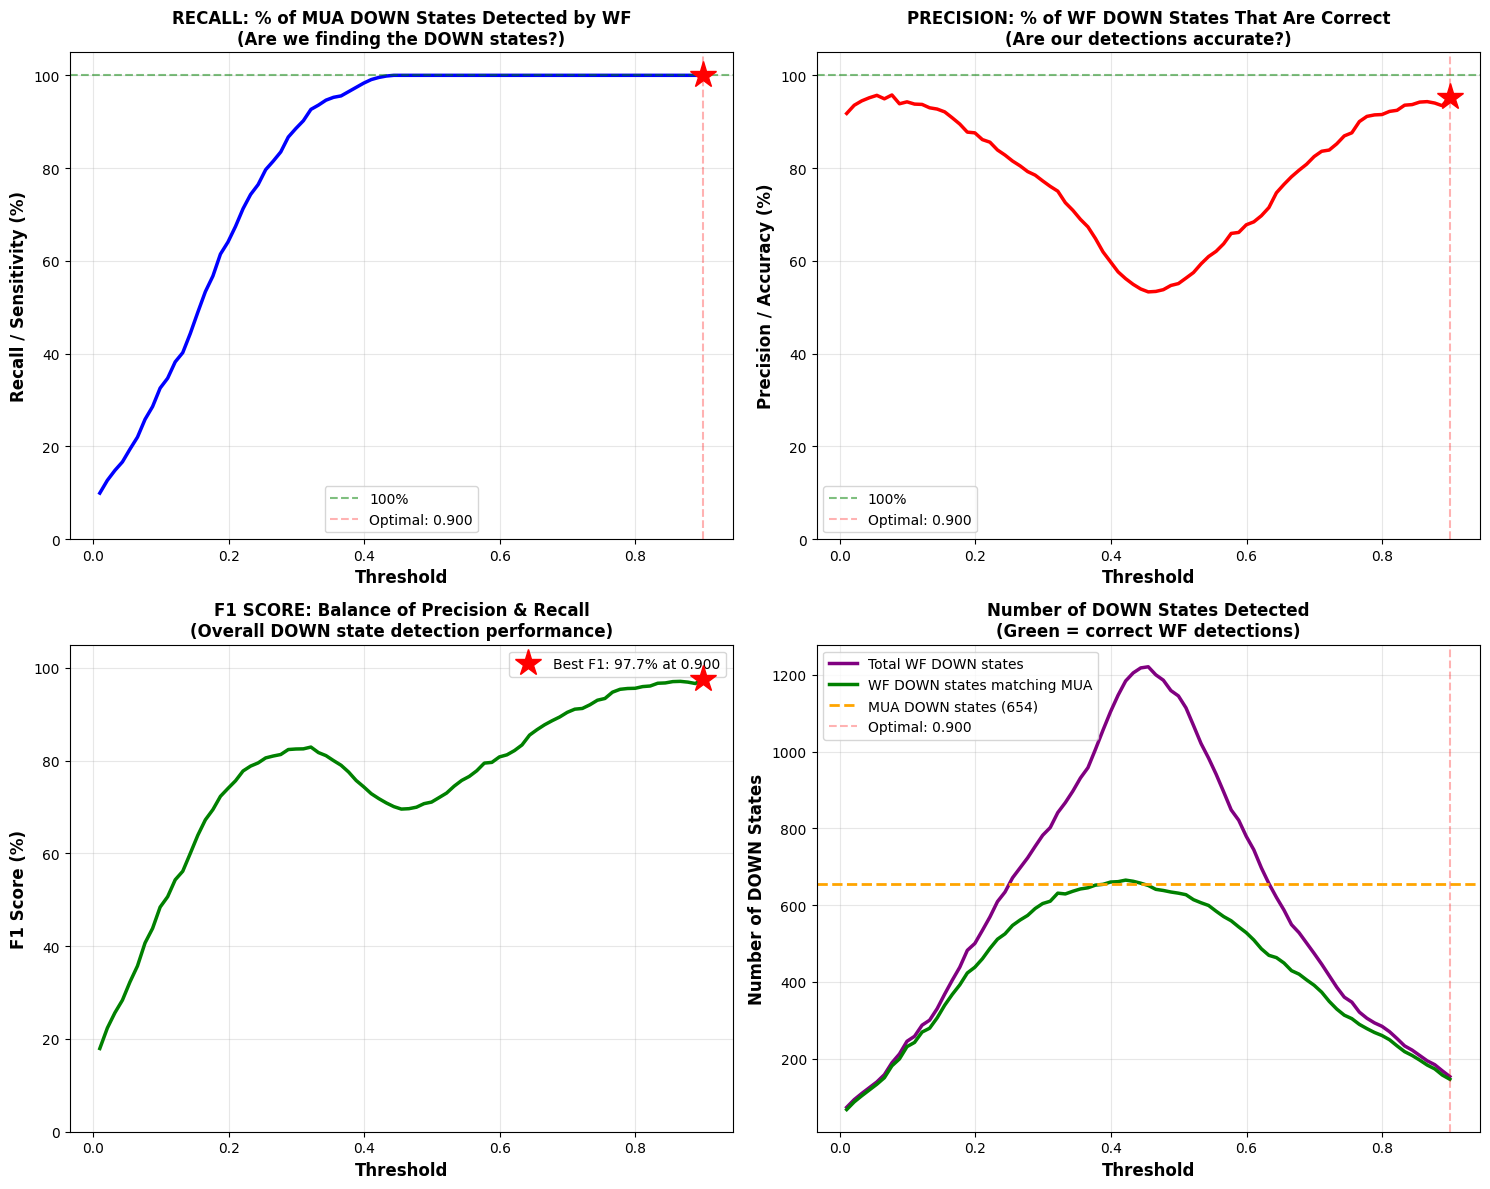

In [17]:
fig, optimal_threshold, result = plot_down_state_detection_with_precision(
    wf_time=wf_time,
    wf_data=wf_aligned,
    mua_downs=downs_in_window,
    thresholds=np.linspace(0.01, 0.9, 81),
    valid_mask=valid_mask
)
plt.savefig(f'{OUTPUT_PATH}/down_state_detection_visualization.pdf', dpi=300, bbox_inches='tight')
plt.show()

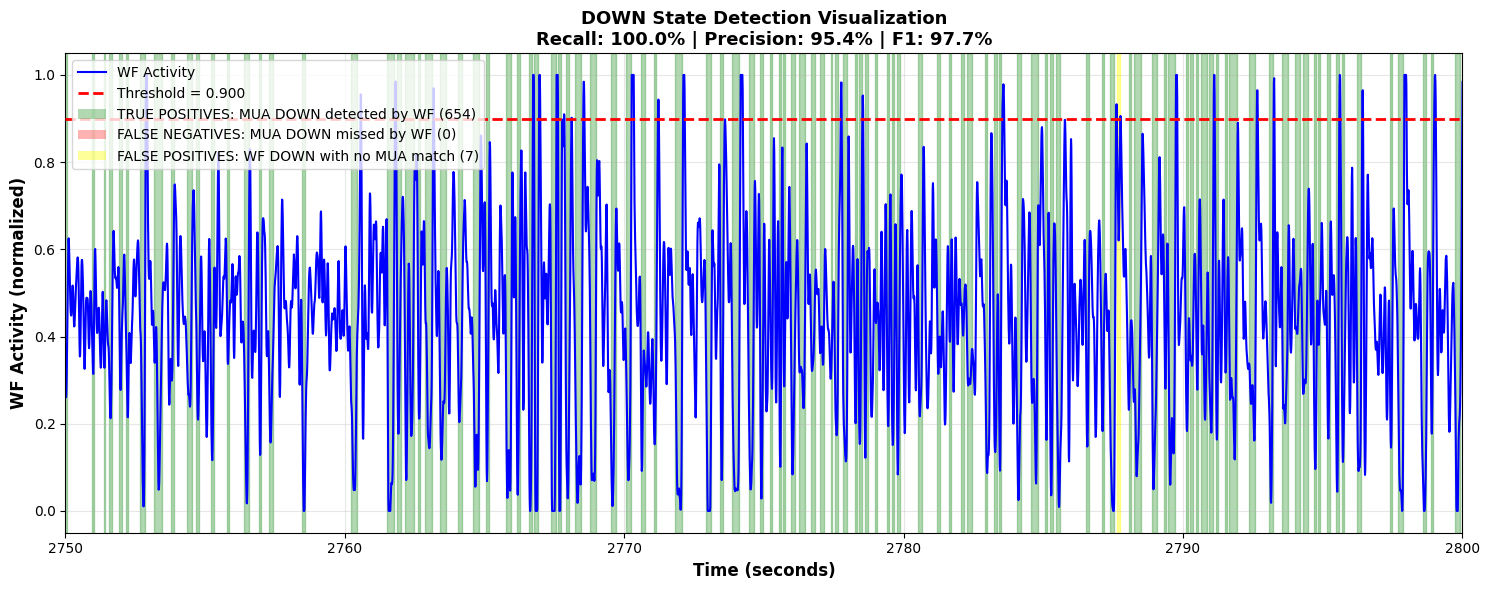

In [18]:
fig_vis, vis_result = visualize_detection_with_precision(
    wf_time=wf_time,
    wf_data=wf_aligned,
    mua_downs=downs_in_window,
    threshold=optimal_threshold,
    time_window=(2750, 2800),  # or None for full window
    valid_mask=valid_mask
)

## Summary

### Quick Reference for Future Use:

1. **Set your time alignment parameters** at the top of the notebook:
   - `WF_START_TIME_IN_MUA`: When does your WF snippet start in MUA time?
   - `WF_END_TIME_IN_MUA`: When does it end?

2. **Run the cells** - the alignment happens automatically!

3. **Access aligned data**:
   - `wf_aligned`: Your WF data aligned to MUA timeline
   - `wf_time`: Time vector in MUA coordinates
   - `mua_binary`: Binary UP/DOWN state at each WF timepoint
   - `valid_mask`: Which timepoints are valid (not filtered)

That's it! No more manual time shifting needed. 🎉